<a href="https://colab.research.google.com/github/comaretto/Big-Data/blob/main/TrabalhoBigData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lista de teste: [1, 3, 5, 7, 9, 11, 13, 15]
Busca Sequencial por 13: (6, 7)
Busca Jump por 13: (6, 5)
Busca Binária por 13: (6, 3)

Processando N = 50...
Processando N = 100...
Processando N = 500...
Processando N = 1000...
Processando N = 5000...
Processando N = 10000...
Processando N = 50000...
Processando N = 100000...
Processando N = 500000...
Processando N = 1000000...

Tabela final de resultados:
         N  tempo_sequencial  comp_sequencial  tempo_jump  comp_jump  \
0       50          0.000010               26    0.000012          9   
1      100          0.000014               51    0.000005          7   
2      500          0.000036              251    0.000009         21   
3     1000          0.000072              501    0.000010         22   
4     5000          0.000659             2501    0.000037         87   
5    10000          0.000935             5001    0.000016         52   
6    50000          0.003547            25001    0.000035        138   
7   100000        

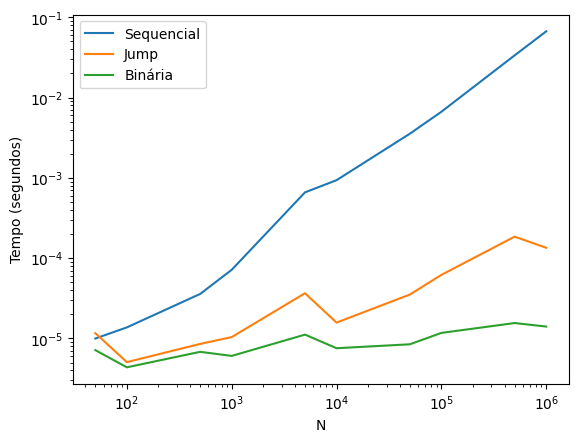

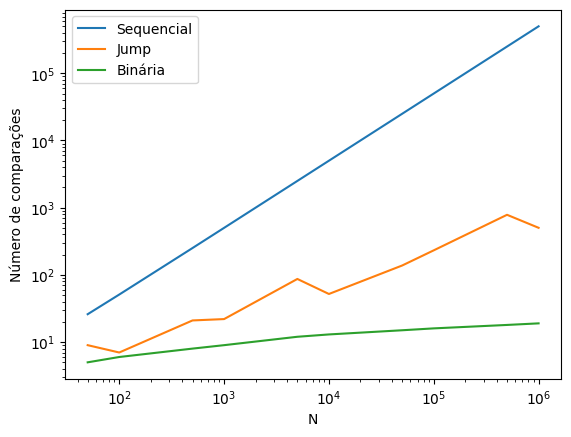


--- Análise de custo oculto (N = 100000) ---
Tempo para ordenar uma vez: 0.001839 s
Tempo de 1 busca sequencial: 0.007156 s
Tempo de 1 busca binária: 0.000014 s

Com 1 buscas:
  Só sequencial (sem ordenar): 0.007156 s
  Ordenar + busca binária:     0.001853 s
  -> Nesse ponto, JÁ COMPENSA ordenar e usar busca binária.

Com 10 buscas:
  Só sequencial (sem ordenar): 0.071556 s
  Ordenar + busca binária:     0.001981 s
  -> Nesse ponto, JÁ COMPENSA ordenar e usar busca binária.

Com 100 buscas:
  Só sequencial (sem ordenar): 0.715557 s
  Ordenar + busca binária:     0.003265 s
  -> Nesse ponto, JÁ COMPENSA ordenar e usar busca binária.

Com 1000 buscas:
  Só sequencial (sem ordenar): 7.155570 s
  Ordenar + busca binária:     0.016099 s
  -> Nesse ponto, JÁ COMPENSA ordenar e usar busca binária.

Com 10000 buscas:
  Só sequencial (sem ordenar): 71.555700 s
  Ordenar + busca binária:     0.144439 s
  -> Nesse ponto, JÁ COMPENSA ordenar e usar busca binária.



In [3]:
import numpy as np
import timeit
import math
import matplotlib.pyplot as plt
import pandas as pd


def busca_sequencial(lista, alvo):
    num_comp = 0
    for i in range(len(lista)):
        num_comp = num_comp + 1
        if lista[i] == alvo:
            return i, num_comp
    return -1, num_comp


def busca_jump(lista, alvo):
    n = len(lista)
    passo = int(math.sqrt(n))
    num_comp = 0
    inicio = 0
    fim = 0

    while fim < n:
        fim = fim + passo
        if fim > n:
            fim = n
        num_comp = num_comp + 1
        if lista[fim - 1] >= alvo:
            break
        inicio = fim

    for i in range(inicio, fim):
        num_comp = num_comp + 1
        if lista[i] == alvo:
            return i, num_comp
        if lista[i] > alvo:
            break

    return -1, num_comp


def busca_binaria(lista, alvo):
    inicio = 0
    fim = len(lista) - 1
    num_comp = 0

    while inicio <= fim:
        meio = (inicio + fim) // 2
        num_comp = num_comp + 1
        if lista[meio] == alvo:
            return meio, num_comp
        elif lista[meio] < alvo:
            inicio = meio + 1
        else:
            fim = meio - 1

    return -1, num_comp


teste_lista = [1, 3, 5, 7, 9, 11, 13, 15]
print("Lista de teste:", teste_lista)
print("Busca Sequencial por 13:", busca_sequencial(teste_lista, 13))
print("Busca Jump por 13:", busca_jump(teste_lista, 13))
print("Busca Binária por 13:", busca_binaria(teste_lista, 13))
print()


lista_de_n = [50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]

lista_n_resultado = []
lista_tempo_sequencial = []
lista_comp_sequencial = []
lista_tempo_jump = []
lista_comp_jump = []
lista_tempo_binaria = []
lista_comp_binaria = []

for n in lista_de_n:
    print(f"Processando N = {n}...")

    dados = np.random.randint(0, n * 10, size=n)
    dados_ordenados = np.sort(dados)
    alvo = int(dados_ordenados[n // 2])

    tempo_sequencial = timeit.timeit(lambda: busca_sequencial(dados_ordenados, alvo), number=1)
    tempo_jump = timeit.timeit(lambda: busca_jump(dados_ordenados, alvo), number=1)
    tempo_binaria = timeit.timeit(lambda: busca_binaria(dados_ordenados, alvo), number=1)

    _, comp_sequencial = busca_sequencial(dados_ordenados, alvo)
    _, comp_jump = busca_jump(dados_ordenados, alvo)
    _, comp_binaria = busca_binaria(dados_ordenados, alvo)

    lista_n_resultado.append(n)
    lista_tempo_sequencial.append(tempo_sequencial)
    lista_comp_sequencial.append(comp_sequencial)
    lista_tempo_jump.append(tempo_jump)
    lista_comp_jump.append(comp_jump)
    lista_tempo_binaria.append(tempo_binaria)
    lista_comp_binaria.append(comp_binaria)


tabela_resultados = pd.DataFrame({
    "N": lista_n_resultado,
    "tempo_sequencial": lista_tempo_sequencial,
    "comp_sequencial": lista_comp_sequencial,
    "tempo_jump": lista_tempo_jump,
    "comp_jump": lista_comp_jump,
    "tempo_binaria": lista_tempo_binaria,
    "comp_binaria": lista_comp_binaria,
})

print()
print("Tabela final de resultados:")
print(tabela_resultados)

tabela_resultados.to_csv("resultados_busca.csv", index=False)


plt.plot(tabela_resultados["N"], tabela_resultados["tempo_sequencial"], label="Sequencial")
plt.plot(tabela_resultados["N"], tabela_resultados["tempo_jump"], label="Jump")
plt.plot(tabela_resultados["N"], tabela_resultados["tempo_binaria"], label="Binária")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N")
plt.ylabel("Tempo (segundos)")
plt.legend()
plt.show()


plt.plot(tabela_resultados["N"], tabela_resultados["comp_sequencial"], label="Sequencial")
plt.plot(tabela_resultados["N"], tabela_resultados["comp_jump"], label="Jump")
plt.plot(tabela_resultados["N"], tabela_resultados["comp_binaria"], label="Binária")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N")
plt.ylabel("Número de comparações")
plt.legend()
plt.show()


n_teste = 100000
dados_teste = np.random.randint(0, n_teste * 10, size=n_teste)
alvo_teste = int(dados_teste[n_teste // 2])

tempo_ordenacao = timeit.timeit(lambda: np.sort(dados_teste), number=1)
dados_teste_ordenados = np.sort(dados_teste)

tempo_uma_busca_sequencial = timeit.timeit(lambda: busca_sequencial(dados_teste, alvo_teste), number=1)
tempo_uma_busca_binaria = timeit.timeit(lambda: busca_binaria(dados_teste_ordenados, alvo_teste), number=1)

print()
print("--- Análise de custo oculto (N = 100000) ---")
print(f"Tempo para ordenar uma vez: {tempo_ordenacao:.6f} s")
print(f"Tempo de 1 busca sequencial: {tempo_uma_busca_sequencial:.6f} s")
print(f"Tempo de 1 busca binária: {tempo_uma_busca_binaria:.6f} s")
print()

quantidades_de_buscas = [1, 10, 100, 1000, 10000]

for quantidade in quantidades_de_buscas:
    custo_so_sequencial = tempo_uma_busca_sequencial * quantidade
    custo_ordenar_e_binaria = tempo_ordenacao + (tempo_uma_busca_binaria * quantidade)

    print(f"Com {quantidade} buscas:")
    print(f"  Só sequencial (sem ordenar): {custo_so_sequencial:.6f} s")
    print(f"  Ordenar + busca binária:     {custo_ordenar_e_binaria:.6f} s")
    if custo_ordenar_e_binaria < custo_so_sequencial:
        print("  -> Nesse ponto, JÁ COMPENSA ordenar e usar busca binária.")
    else:
        print("  -> Ainda NÃO compensa ordenar. Sequencial ainda é mais barato.")
    print()